In [3]:
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Reading the Data

In [4]:
train_df = pd.read_csv('/content/drive/MyDrive/titanic/train.csv')

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


.info를 사용하면 데이터를 표면적으로 빠르게 조사할 수 있습니다. 이제 각 열 이름과 해당 열에 있는 값의 개수를 확인할 수 있습니다. 나이, 객실, 승선 장소, 승선한 날짜 등 세 열에 결측값이 있는 것을 알 수 있습니다. 때로는 데이터 학습에 가장 유용한 열을 파악하기 위해 전체 행을 살펴보는 것이 유용할 수 있습니다.

In [6]:
train_df.loc[0]

,0
PassengerId,1
Survived,0
Pclass,3
Name,"Braund, Mr. Owen Harris"
Sex,male
Age,22.0
SibSp,1
Parch,0
Ticket,A/5 21171
Fare,7.25


먼저, 이름(Name) 범주를 삭제하면 생존(Survived) 범주에는 아무런 영향이 없다는 것을 알 수 있습니다. 티켓(Ticket) 클래스도 그다지 유용하지 않습니다. 티켓 클래스는 모든 티켓이 순수한 숫자가 아니기 때문에 포함할 경우 범주형 변수가 된다는 점을 명심하십시오. 유용한 정보를 제공하지 않는 승객 ID(PassengerId)도 삭제하겠습니다. 이 튜토리얼에서는 결측값이 많기 때문에 객실(Cabin) 범주는 사용하지 않겠습니다.

In [7]:
#Drop Name and Ticket
train_df.drop(['Name', 'Ticket', 'PassengerId', 'Cabin'], axis=1, inplace=True)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


다음으로 넘어가기 전에, 학습에 필요한 데이터를 준비하기 위해 train_df를 X와 y로 분할해 보겠습니다.

In [8]:
X = train_df.drop('Survived', axis=1, inplace=False)
y = train_df['Survived']

print(f'Input features shape: {X.shape}')
print(f'Labels shape: {y.shape}')

Input features shape: (891, 7)
Labels shape: (891,)


# Data Analysis

In [10]:
#Import visualization libraries
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

데이터 불균형의 증거를 찾기 위해 목표 변수를 빠르게 살펴보겠습니다.

Text(0, 0.5, 'Number of Passengers')

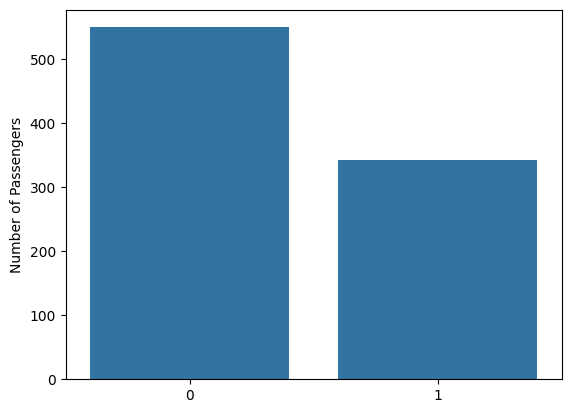

In [11]:
sns.barplot(x = y.unique(), y = y.value_counts())
plt.ylabel('Number of Passengers')

다행히 이 데이터셋의 불균형은 심각하지 않습니다. 이제 어떤 특징에 결측값이 있는지 살펴보겠습니다.

   Pclass  Sex  Age  SibSp  Parch  Fare  Embarked
0     891  891  714    891    891   891       889


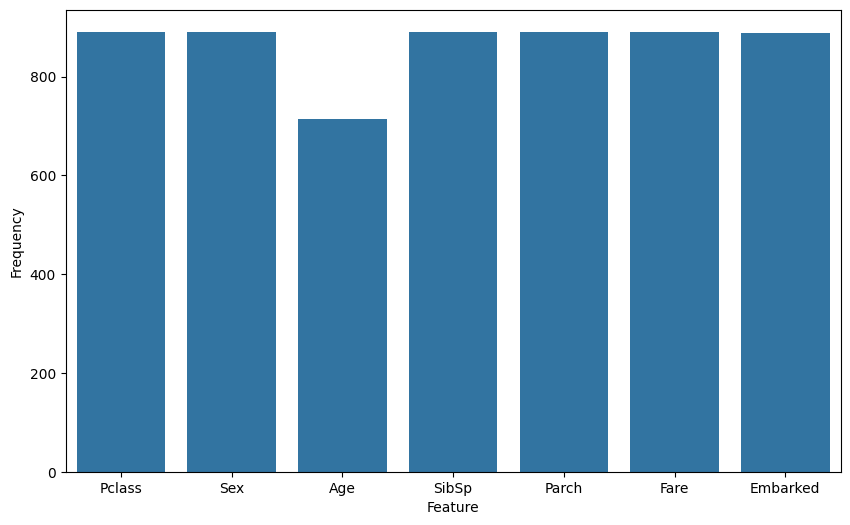

In [12]:
frequencies = X.count()

freq_df = pd.DataFrame([frequencies], columns=X.columns)
print(freq_df.head())

plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y = frequencies)
plt.ylabel('Frequency')
plt.xlabel('Feature')
plt.show()

위 그림에서 알 수 있듯이, 연령(Age) 범주에 결측값이 상당히 많습니다. 또한, 나열된 값 중에서 '출발(Embarked)' 범주에도 2개의 결측값이 있습니다. 다행히 Sci-kit Learn은 간단한 결측값 대체 기능을 제공하여 이러한 결측값을 손쉽게 대체할 수 있도록 해줍니다.

# Imputing and One-Hot Encoding

결측값 대체는 결측값을 처리하는 과정입니다. 이 문제를 해결하는 가장 기본적인 방법은 결측값이 포함된 모든 인스턴스/행을 제거하는 것입니다. 하지만 이렇게 하면 학습 인스턴스가 714개밖에 남지 않아 891개보다 훨씬 적어집니다. 따라서 SimpleImputer API를 사용합니다.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('cat_imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder())
])

In [14]:
#Combine Pipelines

from sklearn.compose import ColumnTransformer

num_attribs = ['Age', 'SibSp', 'Parch', 'Fare']
cat_attribs = ['Pclass', 'Sex', 'Embarked']

full_pipeline = ColumnTransformer([("num", num_pipeline, num_attribs),
                                   ("cat", cat_pipeline, cat_attribs)])
X = full_pipeline.fit_transform(X)
X.shape

(891, 12)

데이터 준비가 완료되었으므로 이제 scikit-learn의 train_test_split 함수를 사용하여 데이터를 훈련 세트와 검증 세트로 분할할 준비가 되었습니다.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Neural Network

이제 모든 준비가 끝났으니 모델 구축을 시작해 보겠습니다! TensorFlow를 사용하여 이 문제를 해결할 간단한 신경망을 만드는 방법을 살펴보겠습니다. 현재는 은닉층 2개와 출력층에 뉴런 1개를 사용하는 간단한 신경망(이진 문제)을 구현합니다

In [16]:
#Import necessary libraries

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers as L

텐서플로우에서 신경망을 만드는 과정

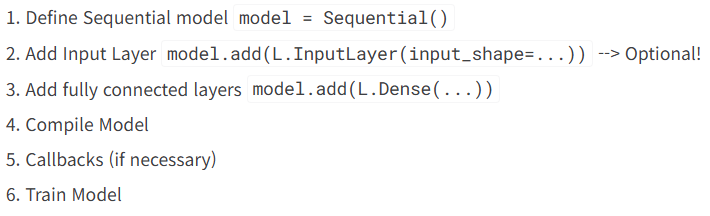

In [17]:
#Step 1
model = Sequential(name='titanic_model')

#Step 2
model.add(L.InputLayer(input_shape=(12,))) # necessary to use model.summary()

#Step 3
model.add(L.Dense(512, activation='relu'))
model.add(L.Dense(1024, activation='relu'))
model.add(L.Dropout(0.4)) #prevents overfitting by setting 40% of nuerons to 0
model.add(L.Dense(512, activation='relu'))
model.add(L.Dropout(0.4))
model.add(L.Dense(128, activation='relu'))
model.add(L.Dense(64, activation='relu'))
model.add(L.Dense(64, activation='relu'))
model.add(L.Dense(1, activation='sigmoid')) # output layer, use sigmoid for binary

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "titanic_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,134,913 (4.33 MB)

 Trainable params: 1,134,913 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Step 4
model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(0.0001), metrics=['accuracy'])

In [19]:
#Step 5
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_accuracy')>0.83):
            print("\nReached 83% accuracy so cancelling training!")
            self.model.stop_training = True


#Step 6
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    batch_size=8,
                    callbacks=[myCallback()],
                    epochs=50)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6320 - loss: 0.6350 - val_accuracy: 0.7765 - val_loss: 0.5499
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7781 - loss: 0.5102 - val_accuracy: 0.7989 - val_loss: 0.4668
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8244 - loss: 0.4480 - val_accuracy: 0.8156 - val_loss: 0.4338
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8188 - loss: 0.4371 - val_accuracy: 0.8212 - val_loss: 0.4329
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8258 - loss: 0.4155 - val_accuracy: 0.7989 - val_loss: 0.4508
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8329 - loss: 0.4038 - val_accuracy: 0.8212 - val_loss: 0.4317
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8272 - loss: 0.4096 - val_accuracy: 0.8212 - val_loss: 0.4459
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8385 - loss: 0.4001 - val_accuracy: 0.8268 - v

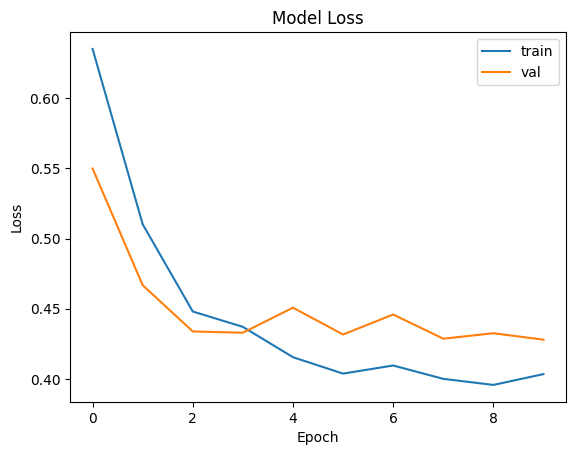

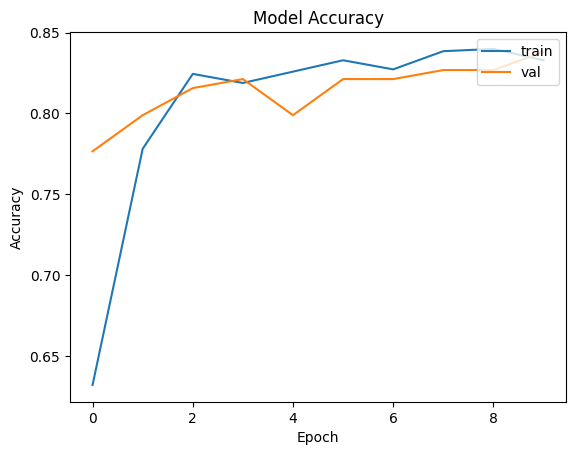

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['train', 'val'], loc='upper right')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['train', 'val'], loc='upper right')
plt.show()

위 그래프에서 알 수 있듯이, 학습 손실은 지속적으로 감소하는 반면 검증 손실은 처음 몇 에포크 이후부터 증가하기 시작합니다. 이는 과적합의 좋은 징후입니다.

# Prepare the Test Data
학습 데이터에서 했던 것처럼 데이터를 삭제해야 합니다. 그런 다음 이전과 동일한 파이프라인을 사용하여 데이터를 변환합니다. 이후 예측값이 0.5보다 크면 생존했다고 판단합니다. 마지막으로 제출할 수 있습니다.

In [21]:
test_df = pd.read_csv('/content/drive/MyDrive/titanic/test.csv')
test_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
test_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,8.0500,S
414,1,female,39.0,0,0,108.9000,C
415,3,male,38.5,0,0,7.2500,S
416,3,male,NaN,0,0,8.0500,S


In [22]:
test_prepared = full_pipeline.transform(test_df)
test_prepared.shape

(418, 12)

In [23]:
preds = model.predict(test_prepared)
preds[:5]

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[0.12589848],
       [0.51893246],
       [0.09097143],
       [0.15368846],
       [0.3642775 ]], dtype=float32)

In [24]:
submission = pd.read_csv('/content/drive/MyDrive/titanic/submission.csv')
submission['Survived'] = [0 if pred < 0.5 else 1 for pred in preds]
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,0


In [25]:
from IPython.display import FileLink


submission.to_csv('submission.csv',index=False)
FileLink(r'submission.csv')

/content/submission.csv